# Tamara Lane's Notebook - Intro to Jupyter and Exploratory Data Analysis (EDA)

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

REQ: For EDA projects, include dataset, description, and source information.

- Author: [Tamara Lane](https://github.com/TLane521/)
- Repository: [datafun-04-notebooks](https://github.com/TLane521/datafun-04-notebooks/)
- Purpose: Demonstrate a repeatable EDA workflow for a new, unexplored dataset
- Date: 2026-02

## Dataset Information

- Dataset: Planets (seaborn dataset)
- Description: Planet mass, orbital period, distance (from Earth), year observed, method observed, and number (amount of know planets in the system)
- Source: Seaborn built in datasets
- Access: Available via Seaborn's built-in datasets

This is a Markdown cell.

## Section 1. Project Setup and Imports

All imports and configuration appear once, at the top of the notebook.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes it clear what must be installed

This is a Markdown cell.

In [42]:
# This is a Python cell.

# Imports at the top of the file
# REQ.EXTERNAL.DEPS: External packages must be defined in pyproject.toml
# REQ.EXTERNAL.DEPS.INSTALLED: external packages must be installed in the environment using uv sync command
# REQ.EXTERNAL.DEPS.IMPORTED: external packages used in this notebook must be imported here


from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Type hint for Axes object (basic plot type returned by Seaborn)
# A seaborn plot is a set of axes and you can set the title, labels, etc. on the axes.

# A figure can contain multiple axes (plots)
# from matplotlib.figure import Figure

# Pandas display configuration (helps in notebooks)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Imports complete.")

Imports complete.


## Section 2. Load the Data

This is a Markdown cell.

WHY: Before analysis, load the data to confirm:

- The dataset loads successfully
- The structure matches expectations
- Column names are available and readable

This is a Markdown cell.

In [43]:
# Python cell

# Load the planets dataset from Seaborn
# Into a pandas DataFrame (2D table)
planets_df: pd.DataFrame = sns.load_dataset("planets")

# Preview the first few rows
planets_df.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


## Section 3. Inspect Data Shape and Structure

WHY: First, understand the shape (basic structure) of the data:

- How many rows and columns are there?
- What types of data are present?
- Are there obvious missing values?

This step determines challenges we might have downstream (later).

This is a Markdown cell.

In [44]:
# Section 3 Python cell

# Get shape - number of rows and columns
shape: tuple[int, int] = planets_df.shape

# Communicate the shape clearly
print(f"The planets dataset has {shape[0]} rows and {shape[1]} columns.")

The planets dataset has 1035 rows and 6 columns.


In [45]:
# Section 3 Python cell

# Display column names and data types
planets_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   method          1035 non-null   str    
 1   number          1035 non-null   int64  
 2   orbital_period  992 non-null    float64
 3   mass            513 non-null    float64
 4   distance        808 non-null    float64
 5   year            1035 non-null   int64  
dtypes: float64(3), int64(2), str(1)
memory usage: 48.6 KB


In [46]:
# Section 3 Python cell

# List the column names
print("Column names:")
print(list(planets_df.columns))

Column names:
['method', 'number', 'orbital_period', 'mass', 'distance', 'year']


## Section 4. Create Data Dictionary and Check Data Quality

WHY: Missing data is normal. We need to find out how much and where.

Missing data affects:

- Visualizations
- Summary statistics
- Machine learning models

LOOK FOR: 

- Columns with many missing values
- Patterns (entire rows missing multiple fields)

This is a Markdown cell.


In [47]:
# Section 4 Python cell

# Count missing values in each column
print("Missing values per column:")
print(planets_df.isnull().sum())

Missing values per column:
method              0
number              0
orbital_period     43
mass              522
distance          227
year                0
dtype: int64


In [48]:
# Section 4 Python cell

# Check for duplicate rows
num_duplicates = planets_df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 4


## Section 5. Create Clean View for EDA

WHY: We often want to work with complete data for visualizations and statistics.

Strategy:
- Keep the original DataFrame unchanged
- Create a separate clean view by dropping rows with missing values

This is a Markdown cell.

In [49]:
# Section 5 Python cell

# Create a clean view by dropping rows with any missing values
planets_clean: pd.DataFrame = planets_df.dropna()

# Compare sizes
print(f"Original dataset: {len(planets_df)} rows")
print(f"Clean dataset: {len(planets_clean)} rows")
print(f"Rows removed: {len(planets_df) - len(planets_clean)}")

Original dataset: 1035 rows
Clean dataset: 498 rows
Rows removed: 537


## Section 6. Descriptive Statistics for Numeric Columns

WHY: Summary statistics give us a quick overview of the numeric data:

- Central tendency (mean)
- Spread (std, min, max)
- Distribution shape (quartiles)

This is a Markdown cell.

In [50]:
# Section 6 Python cell

# Summary statistics for numeric columns
planets_clean.describe()

,number,orbital_period,mass,distance,year
count,498.00000,498.000000,498.000000,498.000000,498.000000
mean,1.73494,835.778671,2.509320,52.068213,2007.377510
std,1.17572,1469.128259,3.636274,46.596041,4.167284
min,1.00000,1.328300,0.003600,1.350000,1989.000000
25%,1.00000,38.272250,0.212500,24.497500,2005.000000
50%,1.00000,357.000000,1.245000,39.940000,2009.000000
75%,2.00000,999.600000,2.867500,59.332500,2011.000000
max,6.00000,17337.500000,25.000000,354.000000,2014.000000


In [51]:
# Section 6 Python cell

# AND/OR Calculate statistics for a specific column with numpy
mean_orbital_period = np.mean(planets_clean["orbital_period"])
std_orbital_period = np.std(planets_clean["orbital_period"])
min_orbital_period = np.min(planets_clean["orbital_period"])
max_orbital_period = np.max(planets_clean["orbital_period"])
range_orbital_period = np.ptp(
    planets_clean["orbital_period"]
)  # peak to peak (max - min)

print("Body Mass Statistics (using numpy):")
print(f"  Mean: {mean_orbital_period:.2f} g")
print(f"  Std Dev: {std_orbital_period:.2f} g")
print(f"  Min: {min_orbital_period:.2f} g")
print(f"  Max: {max_orbital_period:.2f} g")
print(f"  Range: {range_orbital_period:.2f} g")

Body Mass Statistics (using numpy):
  Mean: 835.78 g
  Std Dev: 1467.65 g
  Min: 1.33 g
  Max: 17337.50 g
  Range: 17336.17 g


## Section 7. Correlation Matrix for Numeric Columns

WHY: Correlation tells us how numeric variables relate to each other.

- Values near 1 or -1 indicate strong relationships
- Values near 0 indicate weak or no linear relationship

This is a Markdown cell.

In [52]:
# Section 7 Python cell

# Select only numeric columns and compute correlation
numeric_cols = planets_clean.select_dtypes(include="number")
correlation_matrix = numeric_cols.corr()
print(correlation_matrix)

                  number  orbital_period      mass  distance      year
number          1.000000       -0.059435 -0.249915 -0.288808  0.110399
orbital_period -0.059435        1.000000  0.184906 -0.035069  0.070186
mass           -0.249915        0.184906  1.000000  0.274082 -0.137946
distance       -0.288808       -0.035069  0.274082  1.000000  0.193087
year            0.110399        0.070186 -0.137946  0.193087  1.000000


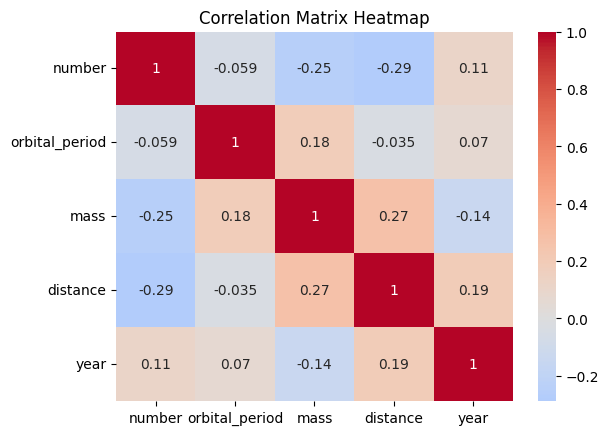

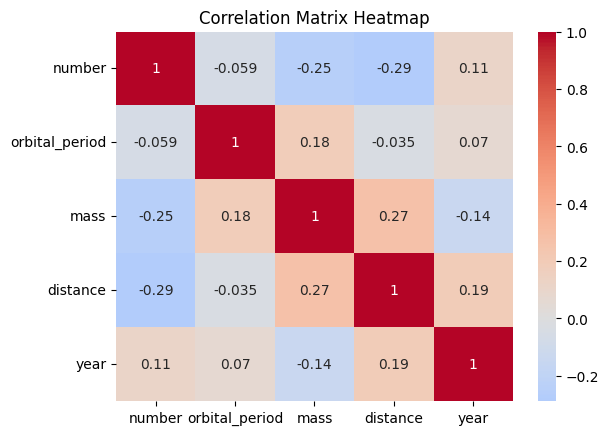

In [53]:
# Section 7 Python cell

# Visualize the correlation matrix as a heatmap
# Set annotations to True to show correlation values
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix Heatmap")
plt.show()


# Visualize the correlation matrix as a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix Heatmap")
plt.show()


Use Markdown cells to narrate and tell the story as you explore.

Interpretation:

 - Values close to 1 (dark red) = strong positive correlation (both increase together)
 - Values close to -1 (dark blue) = strong negative correlation (one increases, other decreases)
 - Values close to 0 (white) = little or no linear relationship
 - The diagonal is always 1 (each variable correlates perfectly with itself)

From this heatmap, we can see that **flipper_length_mm** and **body_mass_g** show strong positive correlation (~0.87).

This is a Markdown cell.

## Section 8. Make Plots

WHY: Visualizations reveal patterns not obvious in tables.

Create:
1. A scatter plot to see relationships between two variables
2. A box plot to compare distributions across groups

This is a Markdown cell.

Text(0.5, 1.0, 'Chart 1. Planets Mass vs. Orbital Period (by Number)')

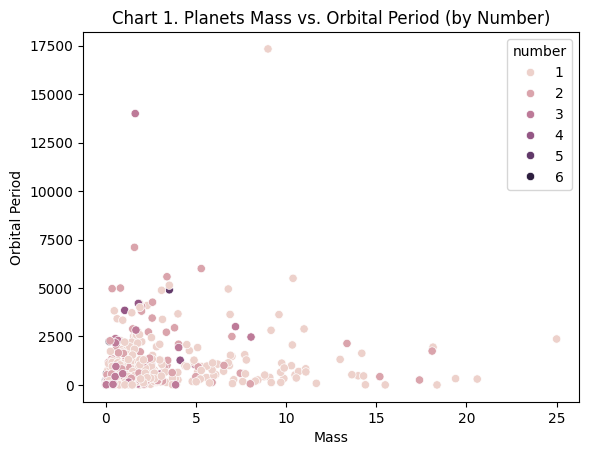

In [54]:
# Section 8 Python cell - use "Run All" so prior cells are executed first.

# Create a scatter plot of penguin flipper length vs. body mass
# We need to know our dataset column names so we can use them to set x, y, and hue (color)
scatter_plt: Axes = sns.scatterplot(
    data=planets_clean, x="mass", y="orbital_period", hue="number"
)

# Set axis labels using the Matplotlib Axes methods set_xlabel() and set_ylabel()
scatter_plt.set_xlabel("Mass")
scatter_plt.set_ylabel("Orbital Period")

# Set the title using the Matplotlib Axes set_title() method
scatter_plt.set_title("Chart 1. Planets Mass vs. Orbital Period (by Number)")

# Run by clicking Run All in the Menu up top

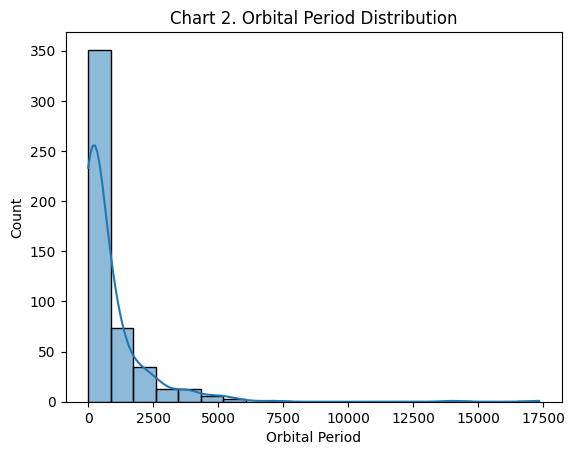

In [55]:
# Section 8 Python cell - histogram of total bills

hist_plt: Axes = sns.histplot(data=planets_clean, x="orbital_period", bins=20, kde=True)
hist_plt.set_title("Chart 2. Orbital Period Distribution")
hist_plt.set_xlabel("Orbital Period")
hist_plt.set_ylabel("Count")
plt.show()

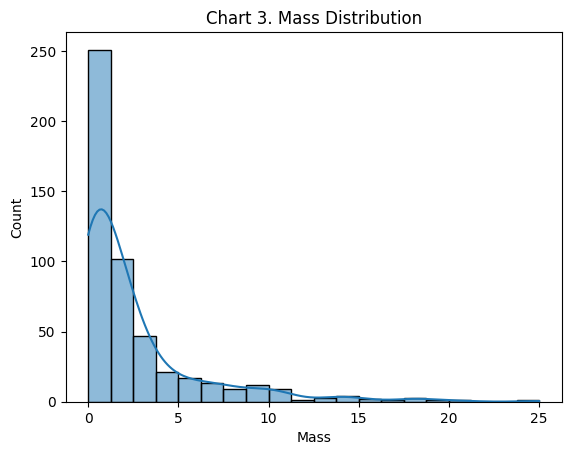

In [56]:
# Section 8 Python cell - histogram of tip amounts

tip_hist_plt: Axes = sns.histplot(data=planets_clean, x="mass", bins=20, kde=True)
tip_hist_plt.set_title("Chart 3. Mass Distribution")
tip_hist_plt.set_xlabel("Mass")
tip_hist_plt.set_ylabel("Count")
plt.show()

## Section 9. Reminder: Run All before sending to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook. 

This is a Markdown cell.
